### Standard YOLO calibration

In [ ]:
import pickle
import os
import torch
import contextlib
import numpy as np
import json
import yolo_patch_sigmoid_std
import math
import numpy as np
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import skimage.io as io
from ultralytics import YOLO 
from dotenv import load_dotenv
from tqdm import tqdm  # For progress tracking
import time
load_dotenv()  # This loads from .env in the current directory

True

In [3]:
def compute_iou(box1, box2):
    """
    Computes IoU between two bounding boxes.
    box format: [x1, y1, x2, y2]
    """

    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])

    # Compute the area of intersection rectangle
    inter_width = max(0, x2_inter - x1_inter)
    inter_height = max(0, y2_inter - y1_inter)
    inter_area = inter_width * inter_height

    # Compute the area of both bounding boxes
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Compute the IoU
    union_area = box1_area + box2_area - inter_area
    iou = inter_area / union_area if union_area > 0 else 0

    return iou

def bin_index(scale, bin_vector):
    """
    Computes the bin index for a given scale and bin vector.
    """
    bin_index = -1
    for i in range(len(bin_vector)):
        if scale <= bin_vector[i] or scale > bin_vector[-1]:
            break
        bin_index += 1

    if bin_index == -1: bin_index = 0

    return bin_index

In [4]:
# === Load YOLO model ===
yolo_model = YOLO("yolo11x.pt")  # Swap with yolov8s.pt or yolov8x.pt as needed

In [5]:
# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
yolo_model = yolo_model.to(device)

Using device: cuda:0


In [6]:
# Load annotations for both datasets
cocos = {
    "train2017": COCO(os.path.join(os.getenv("COCO_DATA"), "annotations/instances_train2017.json")),
    "val2017": COCO(os.path.join(os.getenv("COCO_DATA"), "annotations/instances_val2017.json")),
}

loading annotations into memory...
Done (t=32.72s)
creating index...
index created!
loading annotations into memory...
Done (t=0.89s)
creating index...
index created!


In [7]:
# === Helper: Get COCO split for a given image ID ===
def find_split_for_image(img_id):
    for split, coco_obj in cocos.items():
        if img_id in coco_obj.imgs:
            return split, coco_obj
    return None, None

In [8]:
# === IoU threshold for filtering ===
IOU_THRESHOLD = 0.5

# Confidence bins
bins = np.array([0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 
                 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 
                 0.95, 1.0])

# Counters for statistics
num_imgs = 0

true_positive = 0
false_positive = 0
false_negative = 0

total_preds = 0
total_anns = 0
correct_preds = 0

# Vectors for storing statistics
predicted_classes = []
confidence_scores = []
correct_or_not = []

# For visualization
display_stats = 0

# Loop through every image in the dataset
for split, coco_obj in cocos.items():
    
    # Get all image IDs
    img_ids = coco_obj.getImgIds()
    
    # Loop through each image ID
    for img_id in tqdm(img_ids, desc=f"Processing {len(img_ids)} images in {split}", unit="image"):

        # Update the number of images processed
        num_imgs += 1

        # Load the image 
        img_data = coco_obj.imgs[img_id]
        img_path = os.path.join(os.getenv("COCO_DATA"), split, img_data["file_name"])
        img = io.imread(img_path)

        if img.ndim == 2:  # grayscale
            img = np.stack([img]*3, axis=-1)

        # Prediction
        results = yolo_model.predict(source=img, device='cuda:0', conf=0.25, iou=0.45, verbose=False, max_det=100)
        
        # Unpack results
        result = results[0] # One image, one result
        xyxy = result.boxes.xyxy
        xywh = result.boxes.xywh
        conf = result.boxes.conf
        cls = result.boxes.cls
        prob_vectors = result.boxes.data[:, 6:]  # Probability vectors for each class

        # Plot the image
        # plt.figure(figsize=(5, 5))
        # plt.imshow(img)
        # plt.axis('off')
        # plt.title(f"Image ID: {img_id}")

        # Load anotations of the image
        ann_ids = coco_obj.getAnnIds(imgIds=img_id)
        anns = coco_obj.loadAnns(ann_ids)

        # Update counters and print number of annotations and detections
        #print(f"Image ID: {img_id}, Annotations: {len(anns)}, Detections: {len(xyxy)}")
        total_preds += len(xyxy)
        total_anns += len(anns)

        # Loop through every ground truth annotation
        for ann in anns:
            # Extract bounding box and class information
            bbox = ann["bbox"]
            x1_gt, y1_gt, w_gt, h_gt = bbox
            x2_gt = x1_gt + w_gt
            y2_gt = y1_gt + h_gt

            # Found flag
            found = False

            # Plot ground truth box
            # plt.gca().add_patch(plt.Rectangle((x1_gt, y1_gt), w_gt, h_gt, fill=False, edgecolor="green", linewidth=2))
            # plt.text(x1_gt, y1_gt, f"{coco_obj.loadCats([ann['category_id']])[0]['name']}", color="green", fontsize=12)

            # Loop through the detection
            for box_xyxy, box_xywh, c, cl, prob_v in zip(xyxy, xywh, conf, cls, prob_vectors):
                
                # Convert tensors to numpy arrays
                x1, y1, x2, y2 = box_xyxy.tolist()
                cx, cy, w, h = box_xywh.tolist()
                confidence = c.item()
                class_id = int(cl.item()) 
                prob_vector = prob_v.tolist()

                # Compute IoU
                IoU = compute_iou([x1, y1, x2, y2], [x1_gt, y1_gt, x2_gt, y2_gt])

                # Check if IoU is above the threshold
                if IoU > IOU_THRESHOLD:
                    # Print IoU information of ground truth
                    # print(f"\nGROUND TRUTH: {coco_obj.loadCats([ann['category_id']])[0]['name']}")
                    # print(f"DETECTED: {yolo_model.names[class_id]}")

                    # Uopdate vectors for statistics
                    predicted_classes.append(class_id)
                    confidence_scores.append(confidence)

                    # # Plot the detected box
                    # plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="red", linewidth=1))
                    # plt.text(x1, y1, f"{yolo_model.names[class_id]} {confidence:.2f}", color="red", fontsize=12)

                    # Update counters
                    found = True

                    # Check if they match
                    if coco_obj.loadCats([ann['category_id']])[0]['name'] == yolo_model.names[class_id]:
                        # print(f"Correct detection for class {coco_obj.loadCats([ann['category_id']])[0]['name']} with IoU {IoU:.2f}")
                        true_positive += 1
                        correct_preds += 1
                        correct_or_not.append(True)
                    else:
                        # print(f"Incorrect detection for class {coco_obj.loadCats([ann['category_id']])[0]['name']} with IoU {IoU:.2f}")
                        false_positive += 1
                        correct_or_not.append(False)

                    # Remove the current detection from further processing
                    current_index = (xyxy == box_xyxy).all(dim=1).nonzero(as_tuple=True)[0].item()
                    xyxy = torch.cat((xyxy[:current_index], xyxy[current_index+1:]))
                    xywh = torch.cat((xywh[:current_index], xywh[current_index+1:]))
                    conf = torch.cat((conf[:current_index], conf[current_index+1:]))
                    cls = torch.cat((cls[:current_index], cls[current_index+1:]))
                    prob_vectors = torch.cat((prob_vectors[:current_index], prob_vectors[current_index+1:]))

                    # print(f"Number of detections left: {len(xyxy)}")
                    
                    # Then break the loop for this ground truth annotation
                    break
            
            if not found:
                # print(f"\nGROUND TRUTH: {coco_obj.loadCats([ann['category_id']])[0]['name']}")
                # print("NO DETECTION FOUND...")
                false_negative += 1

        # If there are still detections left (with no matching ground truth), plot them
        for box_xyxy, box_xywh, c, cl, prob_v in zip(xyxy, xywh, conf, cls, prob_vectors):
            # print(("\nDETECTION WITHOUT MATCHING GROUND TRUTH:"))
            # print(f"Detected class: {yolo_model.names[int(cl.item())]}, Confidence: {c.item():.2f}")

            # Convert tensors to numpy arrays
            x1, y1, x2, y2 = box_xyxy.tolist()
            cx, cy, w, h = box_xywh.tolist()
            confidence = c.item()
            class_id = int(cl.item()) 
            prob_vector = prob_v.tolist()

            # Plot the detected box
            # plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="blue", linewidth=1))
            # plt.text(x1, y1, f"{yolo_model.names[class_id]} {confidence:.2f}", color="blue", fontsize=12)

            # Update counters
            false_positive += 1

            # Update vectors for statistics
            predicted_classes.append(class_id)
            confidence_scores.append(confidence)
            correct_or_not.append(False)
            
        # Show the plot for the current image
        # plt.tight_layout()
        # plt.title(f"Image ID: {img_id}, Split: {split}")
        # plt.axis('off')
        # plt.show()

        display_stats += 1



Processing 5000 images in val2017: 100%|██████████| 5000/5000 [13:04<00:00,  6.37image/s]


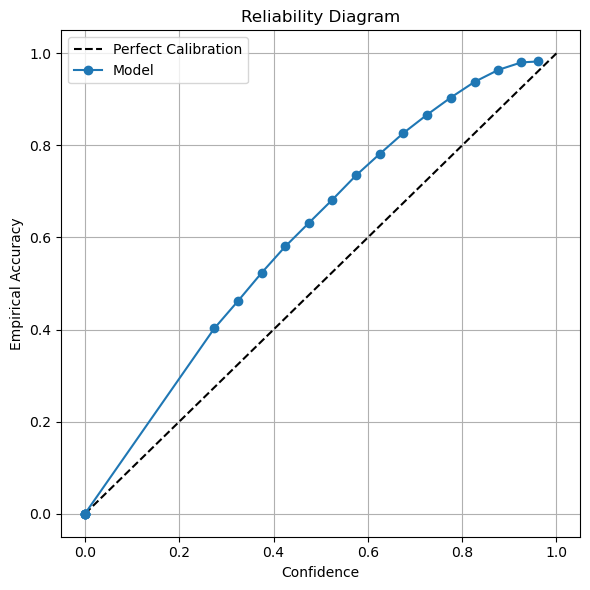

Precision: 0.799
Recall: 0.672
F1 Score: 0.730
ECE: 0.113
MCE: 0.160
Brier Score: 0.137


In [9]:
# === Compute precision, recall, F1 ===
precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0.0
recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0.0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

# === Prepare arrays for calibration metrics ===
confidences = np.array(confidence_scores)
correct = np.array(correct_or_not).astype(int)

# === Bin predictions ===
bin_indices = np.digitize(confidences, bins, right=True) - 1  # bins are right-inclusive
num_bins = len(bins) - 1
bin_counts = np.zeros(num_bins)
bin_correct = np.zeros(num_bins)
bin_conf_sum = np.zeros(num_bins)

for i in range(len(confidences)):
    b = bin_indices[i]
    if 0 <= b < num_bins:
        bin_counts[b] += 1
        bin_correct[b] += correct[i]
        bin_conf_sum[b] += confidences[i]

# === Compute per-bin accuracy and confidence ===
bin_accuracy = np.divide(bin_correct, bin_counts, out=np.zeros_like(bin_correct), where=bin_counts != 0)
bin_conf_avg = np.divide(bin_conf_sum, bin_counts, out=np.zeros_like(bin_conf_sum), where=bin_counts != 0)

# === Compute ECE and MCE ===
total_preds = len(confidences)
ece = np.sum((bin_counts / total_preds) * np.abs(bin_accuracy - bin_conf_avg))
mce = np.max(np.abs(bin_accuracy - bin_conf_avg))

# === Compute Brier Score ===
brier_score = np.mean((confidences - correct) ** 2)

# === Reliability Diagram ===
bin_centers = (bins[:-1] + bins[1:]) / 2
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label="Perfect Calibration")
plt.plot(bin_conf_avg, bin_accuracy, 'o-', label="Model")
plt.xlabel("Confidence")
plt.ylabel("Empirical Accuracy")
plt.title("Reliability Diagram")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Print metrics ===
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1_score:.3f}")
print(f"ECE: {ece:.3f}")
print(f"MCE: {mce:.3f}")
print(f"Brier Score: {brier_score:.3f}")


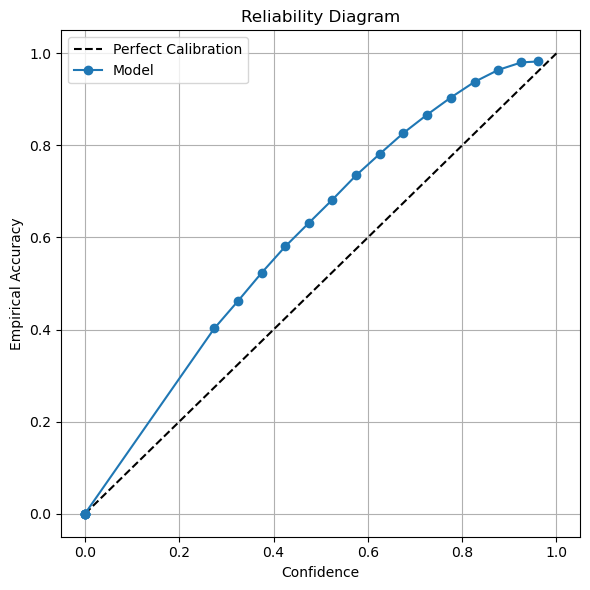

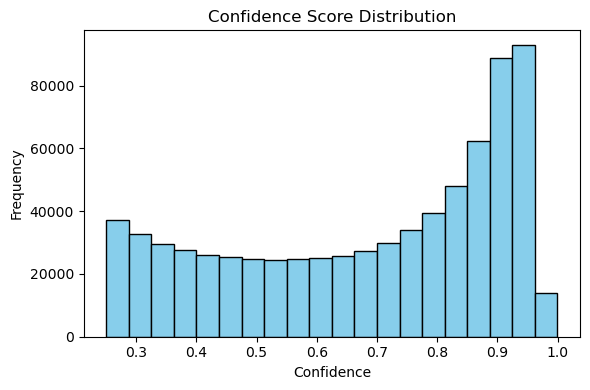

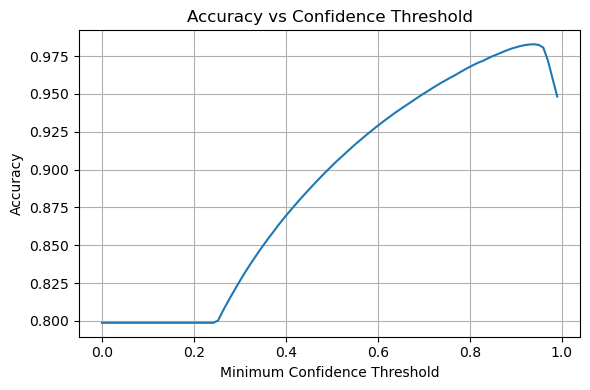

ECE: 0.1133
MCE: 0.1599
Brier Score: 0.1371
Per-class ECE:
  Class 0: ECE = 0.1496
  Class 1: ECE = 0.1340
  Class 2: ECE = 0.1654
  Class 3: ECE = 0.1088
  Class 4: ECE = 0.0938
  Class 5: ECE = 0.0656
  Class 6: ECE = 0.0873
  Class 7: ECE = 0.0427
  Class 8: ECE = 0.1446
  Class 9: ECE = 0.2042
  Class 10: ECE = 0.0833
  Class 11: ECE = 0.0897
  Class 12: ECE = 0.0705
  Class 13: ECE = 0.0589
  Class 14: ECE = 0.1319
  Class 15: ECE = 0.0751
  Class 16: ECE = 0.0563
  Class 17: ECE = 0.0959
  Class 18: ECE = 0.0903
  Class 19: ECE = 0.0972
  Class 20: ECE = 0.0758
  Class 21: ECE = 0.0509
  Class 22: ECE = 0.0856
  Class 23: ECE = 0.0722
  Class 24: ECE = 0.1204
  Class 25: ECE = 0.1250
  Class 26: ECE = 0.0813
  Class 27: ECE = 0.1260
  Class 28: ECE = 0.0557
  Class 29: ECE = 0.0959
  Class 30: ECE = 0.1195
  Class 31: ECE = 0.0647
  Class 32: ECE = 0.1499
  Class 33: ECE = 0.1218
  Class 34: ECE = 0.1373
  Class 35: ECE = 0.1602
  Class 36: ECE = 0.1167
  Class 37: ECE = 0.1357
 

In [10]:
from collections import defaultdict

# Convert to arrays
confidences = np.array(confidence_scores)
correct = np.array(correct_or_not).astype(int)
pred_classes = np.array(predicted_classes)

# Define bins (optional: make finer)
bins = np.linspace(0.0, 1.0, 21)  # 20 bins
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_indices = np.digitize(confidences, bins, right=True) - 1
num_bins = len(bins) - 1

# Bin counters
bin_counts = np.zeros(num_bins)
bin_correct = np.zeros(num_bins)
bin_conf_sum = np.zeros(num_bins)

for i in range(len(confidences)):
    b = bin_indices[i]
    if 0 <= b < num_bins:
        bin_counts[b] += 1
        bin_correct[b] += correct[i]
        bin_conf_sum[b] += confidences[i]

# Per-bin accuracy and average confidence
bin_accuracy = np.divide(bin_correct, bin_counts, out=np.zeros_like(bin_correct), where=bin_counts != 0)
bin_conf_avg = np.divide(bin_conf_sum, bin_counts, out=np.zeros_like(bin_conf_sum), where=bin_counts != 0)

# ECE & MCE
total_preds = len(confidences)
ece = np.sum((bin_counts / total_preds) * np.abs(bin_accuracy - bin_conf_avg))
mce = np.max(np.abs(bin_accuracy - bin_conf_avg))

# Brier Score
brier_score = np.mean((confidences - correct) ** 2)

# === Plot reliability diagram ===
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label="Perfect Calibration")
plt.plot(bin_conf_avg, bin_accuracy, 'o-', label="Model")
plt.xlabel("Confidence")
plt.ylabel("Empirical Accuracy")
plt.title("Reliability Diagram")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Confidence histogram ===
plt.figure(figsize=(6, 4))
plt.hist(confidences, bins=20, color='skyblue', edgecolor='black')
plt.title("Confidence Score Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# === Per-class ECE ===
class_ece = {}
classes = np.unique(pred_classes)

for cls_id in classes:
    idx = pred_classes == cls_id
    cls_conf = confidences[idx]
    cls_corr = correct[idx]
    cls_bins = np.digitize(cls_conf, bins, right=True) - 1
    cls_counts = np.zeros(num_bins)
    cls_correct = np.zeros(num_bins)
    cls_conf_sum = np.zeros(num_bins)
    
    for i in range(len(cls_conf)):
        b = cls_bins[i]
        if 0 <= b < num_bins:
            cls_counts[b] += 1
            cls_correct[b] += cls_corr[i]
            cls_conf_sum[b] += cls_conf[i]
    
    cls_acc = np.divide(cls_correct, cls_counts, out=np.zeros_like(cls_correct), where=cls_counts != 0)
    cls_conf_avg = np.divide(cls_conf_sum, cls_counts, out=np.zeros_like(cls_conf_sum), where=cls_counts != 0)
    cls_ece = np.sum((cls_counts / np.sum(cls_counts)) * np.abs(cls_acc - cls_conf_avg))
    class_ece[cls_id] = cls_ece

# === Accuracy vs Confidence Threshold Curve ===
thresholds = np.linspace(0.0, 1.0, 100)
acc_at_thresh = []

for t in thresholds:
    mask = confidences >= t
    if np.sum(mask) > 0:
        acc = np.mean(correct[mask])
    else:
        acc = np.nan
    acc_at_thresh.append(acc)

plt.figure(figsize=(6, 4))
plt.plot(thresholds, acc_at_thresh, label="Accuracy vs Min Confidence")
plt.xlabel("Minimum Confidence Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Confidence Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Print metrics ===
print(f"ECE: {ece:.4f}")
print(f"MCE: {mce:.4f}")
print(f"Brier Score: {brier_score:.4f}")
print("Per-class ECE:")
for cls_id, val in class_ece.items():
    print(f"  Class {cls_id}: ECE = {val:.4f}")
